# Compressor de imagens com predição linear e codificação de Huffman

Este notebook implementa um pipeline de processamento digital de imagens focado em compressão sem perdas. A arquitetura combina duas abordagens clássicas: a exploração da redundância espacial através de predição linear e a redução da redundância de codificação utilizando Huffman.

## Lendo imagens

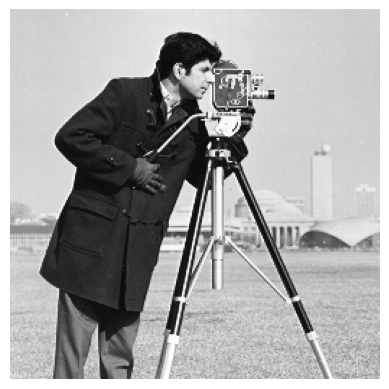

In [322]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import heapq
import numpy as np
IMAGES = ['cameraman.pgm', 'baboon.pgm', 'lena.pgm', 'unequal.pgm', 'tree.pgm', 'road.pgm']
def getImageName(idx):
    return './images/' + IMAGES[idx]
img = mpimg.imread(getImageName(0))
height, width = img.shape
plt.imshow(img, cmap="gray")
plt.axis('off')
plt.show()


## Huffman

In [304]:
def getHistogramMap(img):
    quantidades = dict();
    for row in img:
        for el in row:
            if el in quantidades:
                quantidades[el] += 1     
            else:
                quantidades[el] = 1 
    return quantidades

def huffman(hist):
    queue = [(val, [key]) for (key, val) in hist.items()] 
    heapq.heapify(queue)
    huff_dict = {key : "" for key in hist.keys()}
    
    while len(queue) >= 2:
        val_fr, keys_fr = heapq.heappop(queue)
        val_sn, keys_sn = heapq.heappop(queue)
        nval = val_fr+val_sn
        heapq.heappush(queue, (nval, keys_fr+keys_sn))
        for k in keys_fr:
            huff_dict[k] += '0'
        for k in keys_sn:
            huff_dict[k] += '1'
        
    return {key : val[::-1] for (key, val) in huff_dict.items()} 

def encodeImage(img, huff_dict):
    return "".join(huff_dict[px] for row in img for px in row)

def decodeImage(code, huff_dict, width): 
    class node:
        def __init__(self, end=None):
            self.to = [-1, -1]
            self.end = end
    
    tree = [node()] 
    for key, val in huff_dict.items():
        cur = tree[0];
        for ch in val:
            idx = int(ch)-int('0')
            if cur.to[idx] == -1:
                tree.append(node())
                cur.to[idx] = tree[-1]
            cur = cur.to[idx]
        cur.end = key
    img = []
    cur = tree[0]
    for ch in code:
        idx = int(ch) - int('0')
        cur = cur.to[idx]
        if cur.end is not None:
            img.append(cur.end)
            cur = tree[0]
            
    img = np.array(img)
    return img.reshape(len(img)//width, width)

hist = getHistogramMap(img)
huff_dict = huffman(hist)
encoding = encodeImage(img, huff_dict)
decoding = decodeImage(encoding, huff_dict, width)


## Métricas de avaliação


In [305]:
def MSE(first, second):
    assert(first.shape == second.shape)
    height, width = first.shape
    sum = 0
    for i in range(height):
        for j in range(width):
            sum += (int(first[i][j]) - int(second[i][j]))**2
    return sum/(height*width)

def PSNR(first, second, maxPixelVal=255):
    msr = MSE(first,second)
    if msr == 0: return 50
    return 10 * np.log10(maxPixelVal**2/msr)

def entropy(hist, tot):
    sum = 0
    for _, val in hist.items(): sum += (val/tot) * np.log2(val/tot)
    return -sum

def meanSizeHuffman(hist, dict_huff, tot):
    sum = 0
    for key, val in hist.items(): 
        qtd_bits = len(dict_huff[key])
        sum += (val/tot) * qtd_bits
    return sum
err = MSE(img, decoding)
psnr = PSNR(img, decoding)
err, psnr


(0.0, 50)

- Proximidade do huffman com a entropia da imagem original

In [306]:
height, width = img.shape
init_size = 8 * height * width
encode_size = len(encoding)
entropy = entropy(hist, height * width)
mean_size_huffman = meanSizeHuffman(hist, huff_dict, height * width)
eficiency = entropy/mean_size_huffman


init_size, encode_size, eficiency

(524288, 454324, np.float64(0.9959861768809851))

## Tranformada de cosseno + predição

In [307]:
from scipy.fft import dctn, idctn

QS = [
        np.array([
            [16, 11, 10, 16, 24, 40, 51, 61],
            [12, 12, 14, 19, 26, 58, 60, 55],
            [14, 13, 16, 24, 40, 57, 69, 56],
            [14, 17, 22, 29, 51, 87, 80, 62],
            [18, 22, 37, 56, 68, 109, 103, 77],
            [24, 35, 55, 64, 81, 104, 113, 92],
            [49, 64, 78, 87, 103, 121, 120, 101],
            [72, 92, 95, 98, 112, 100, 103, 99]
        ]),
        # more aggressive quantization
        np.array([
            [32, 22, 20, 32, 48, 80, 102, 122],
            [24, 24, 28, 38, 52, 116, 120, 110],
            [28, 26, 32, 48, 80, 114, 138, 112],
            [28, 34, 44, 58, 102, 174, 160, 124],
            [36, 44, 74, 112, 136, 218, 206, 154],
            [48, 70, 110, 128, 162, 208, 226, 184],
            [98, 128, 156, 174, 206, 242, 240, 202],
            [144,184 ,190 ,196 ,224 ,200 ,206 ,198]
        ]),
        np.array([
            [32, 64, 128, 255, 255, 255, 255, 255],
            [64, 128, 128, 255, 255, 255, 255, 255],
            [128, 128, 255, 255, 255, 255, 255, 255],
            [255, 255, 255, 255, 255, 255, 255, 255],
            [255, 255, 255, 255, 255, 255, 255, 255],
            [255, 255, 255, 255, 255, 255, 255, 255],
            [255, 255, 255, 255, 255, 255, 255, 255],
            [255, 255, 255, 255, 255, 255, 255, 255]
        ])
    ]

def DCT(img, quality=1):
    """
    Retorna a matriz de coeficientes quantizados da DCT e a imagem reconstruída.
    """
    height, width = img.shape
    dct_quant = np.zeros((height, width), dtype=int)
    comp_img_DCT = np.zeros((height, width), dtype=float)
    blockSize = 8

    Q = QS[quality]

    for i in range(0, height, blockSize):
        for j in range(0, width, blockSize):
            block = img[i:i+blockSize, j:j+blockSize]
            coeffs = dctn(block, norm='ortho')
            quant = np.round(coeffs / Q).astype(int)
            deQuant = quant * Q
            dct_quant[i:i+blockSize, j:j+blockSize] = quant
            comp_img_DCT[i:i+blockSize, j:j+blockSize] = idctn(deQuant, norm='ortho')

    return dct_quant, comp_img_DCT

def IDCT(dct_quant, quality=1):
    """
    Reconstrói a imagem espacial a partir da matriz de coeficientes quantizados da DCT.
    """
    height, width = dct_quant.shape
    comp_img_DCT = np.zeros((height, width), dtype=float)
    blockSize = 8

    Q = QS[quality]

    for i in range(0, height, blockSize):
        for j in range(0, width, blockSize):
            deQuant = dct_quant[i:i+blockSize, j:j+blockSize] * Q
            comp_img_DCT[i:i+blockSize, j:j+blockSize] = idctn(deQuant, norm='ortho')
          
    return comp_img_DCT


In [308]:
def quantize_predict(img, dct_img, Q=5):
    """
    Retorna os erros a partir da predição com base nos adjacentes.
    """
    height, width = img.shape

    quantized_errors = np.zeros((height, width), dtype=int)

    rec = np.zeros(img.shape, dtype=float)
    rec_img = np.zeros(img.shape, dtype=float)

    error_target = img.astype(float) - dct_img.astype(float)
    
    for i in range(height):
        for j in range(width):
            pred = 0
            
            if i == 0 and j == 0:
                pred = 0
            elif i == 0:
                pred = rec[i][j-1]
            elif j == 0:
                pred = rec[i-1][j]
            else:
                pred = rec[i-1][j] + rec[i][j-1] - rec[i-1][j-1]

            error = error_target[i][j] - pred
            q_err = int(np.round(error / Q))
            quantized_errors[i][j] = q_err

            rec[i][j] = q_err * Q + pred
            
            rec_img[i][j] = np.clip(rec[i][j] + dct_img[i][j], 0, 255)

    return quantized_errors, rec_img


def dequantize_predict(quantized_errors, dct_img, Q=5):
    """
    Reconstrói a imagem a partir dos erros quantizados e da imagem DCT.
    """
    height, width = quantized_errors.shape

    rec = np.zeros(quantized_errors.shape, dtype=float)
    rec_img = np.zeros(quantized_errors.shape, dtype=float)

    for i in range(height):
        for j in range(width):
            pred = 0
            if i == 0 and j == 0:
                pred = 0
            elif i == 0:
                pred = rec[i][j-1]
            elif j == 0:
                pred = rec[i-1][j]
            else:
                pred = rec[i-1][j] + rec[i][j-1] - rec[i-1][j-1]

            error = quantized_errors[i][j] * Q
            rec[i][j] = error + pred
            
            rec_img[i][j] = np.clip(rec[i][j] + dct_img[i][j], 0, 255)

    return rec_img.astype(np.uint8)


## Pipeline utilizado
- Compressão:
    
    - Leitura da imagem e preparação adaptando o formato da imagem para ser dividida em blocos de 8x8
    - DCT em blocos de 8x8
    - Quantização
    - Predição linear do erro da imagem reconstruída por DCT (aqui também é quantizada, erros pequenos são jogados fora)
    - Codificação de Huffman dos coeficientes do DCT e da predição linear do erro

- Descompressão:
    - Decodificação de Huffman
    - Reconstrução da imagem com a DCT
    - Reconstrução da imagem original com a predição linear do erro
    
A intuição é que podemos ser mais agressivos na compressão da imagem por DCT, pois a predição linear do erro vai recuperar a maior parte da informação perdida. A predição linear do erro é feita com base nos pixels vizinhos, e como a imagem reconstruída por DCT já é uma boa aproximação da imagem original, o erro tende a ser pequeno e fácil de predizer.


In [ ]:
def pad_image(img, block_size=8):
    """
    Adiciona padding repetindo a borda para que as dimensões sejam divisíveis por block_size.
    """
    h, w = img.shape
    pad_h = (block_size - (h % block_size)) % block_size
    pad_w = (block_size - (w % block_size)) % block_size
    if pad_h == 0 and pad_w == 0:
        return img, (h, w)
    padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='edge')
    return padded, (h, w)

def crop_image(img, orig_shape):
    return img[:orig_shape[0], :orig_shape[1]]

def zigzag_scan(block):
    """
    Varredura zigue-zague de um bloco 8x8.
    """
    lines = [[] for _ in range(15)]
    for i in range(8):
        for j in range(8):
            lines[i + j].append((i, j))
    
    result = []
    for s, coords in enumerate(lines):
        if s % 2 == 0:
            coords = reversed(coords)
        for r, c in coords:
            result.append(block[r, c])
    return np.array(result)

def inverse_zigzag(arr):
    """
    Reconstrói o bloco 8x8 a partir do vetor zigue-zague.
    """
    block = np.zeros((8, 8), dtype=arr.dtype)
    lines = [[] for _ in range(15)]
    for i in range(8):
        for j in range(8):
            lines[i + j].append((i, j))
    idx = 0
    for s, coords in enumerate(lines):
        if s % 2 == 0:
            coords = reversed(coords)
        for r, c in coords:
            block[r, c] = arr[idx]
            idx += 1
    return block

def encode_block_tail(zz):
    """
    Retorna [K, v0, v1, ..., vK-1], onde K é a quantidade de coeficientes até o último não-zero.
    """
    nz = np.nonzero(zz)[0]
    if len(nz) == 0:
        return [0]  # Bloco totalmente zerado
    k = int(nz[-1]) + 1
    return [k] + zz[:k].tolist()

def decode_block_tail(stream, pos):
    """
    Decodifica o bloco com base no comprimento K    
    """
    k = stream[pos]
    pos += 1
    block = np.zeros(64, dtype=int)
    if k > 0:
        block[:k] = stream[pos : pos + k]
        pos += k
    return block, pos

def compress(img, Q=5):
    """
    Pipeline de Compressão:
    1. Padding para dimensões múltiplas de 8
    2. DCT 8x8 + Quantização
    3. Zigzag + Truncamento da cauda de zeros em cada bloco
    4. Predição linear sobre a imagem reconstruída pela DCT
    5. Cálculo do resíduo (original - predição) com threshold/dead-zone
    6. Codificação de Huffman (DCT e Resíduos)
    """
    padded_img, orig_shape = pad_image(img, 8)
    H, W = padded_img.shape
    blockSize = 8
    dct_quant, comp_img_DCT = DCT(padded_img)

    # Zigzag + Truncamento de sufixo de zeros 
    all_dct_integers = []
    for i in range(0, H, blockSize):
        for j in range(0, W, blockSize):
            block = dct_quant[i:i+blockSize, j:j+blockSize]
            zz = zigzag_scan(block)
            all_dct_integers.extend(encode_block_tail(zz))
    dct_flat = np.array(all_dct_integers, dtype=int)
    
    # Predição espacial sobre a imagem DCT reconstruída
    quantized_err, _ = quantize_predict(padded_img, comp_img_DCT, Q)
    res_flat = quantized_err.flatten()

    # Huffman
    hist_dct = getHistogramMap(dct_flat.reshape(-1, 1))
    huff_dct = huffman(hist_dct)
    code_dct = encodeImage(dct_flat.reshape(-1, 1), huff_dct)

    hist_res = getHistogramMap(res_flat.reshape(-1, 1))
    huff_res = huffman(hist_res)
    code_res = encodeImage(res_flat.reshape(-1, 1), huff_res)

    return {
        'code_dct': code_dct,
        'huff_dct': huff_dct,
        'code_res': code_res,
        'huff_res': huff_res,
        'padded_shape': (H, W),
        'orig_shape': orig_shape,
        'Q': Q
    }

def decompress(compressed_data):
    """
    Pipeline de Descompressão:
    1. Decodificação Huffman da DCT
    2. Leitura de K coeficientes por bloco -> inverse_zigzag -> IDCT
    3. Predição espacial sobre a imagem DCT reconstruída
    4. Decodificação Huffman dos resíduos
    5. Reconstrução final e recorte (crop) ao tamanho original
    """
    H, W = compressed_data['padded_shape']
    orig_shape = compressed_data['orig_shape']
    blockSize = 8

    # Decodificar DCT
    dct_flat = decodeImage(compressed_data['code_dct'], compressed_data['huff_dct'], 1).flatten()
    dct_quant = np.zeros((H, W), dtype=int)
    pos = 0
    for i in range(0, H, blockSize):
        for j in range(0, W, blockSize):
            zz_block, pos = decode_block_tail(dct_flat, pos)
            dct_quant[i:i+blockSize, j:j+blockSize] = inverse_zigzag(zz_block)

    # Reconstrução da DCT via IDCT
    comp_img_DCT = IDCT(dct_quant)

    res_flat = decodeImage(compressed_data['code_res'], compressed_data['huff_res'], 1).flatten()
    quantize_errors = res_flat.reshape(H, W)

    final_padded = dequantize_predict(quantize_errors, comp_img_DCT, compressed_data['Q'])
    return crop_image(final_padded, orig_shape)


In [316]:
def run(img):
    # Teste do Pipeline Completo (Compressão e Descompressão)
    data = compress(img, Q=10)
    recon = decompress(data)

    err = MSE(img, recon)
    psnr_val = PSNR(img, recon)
    orig_bits = img.size * 8
    comp_bits = len(data['code_dct']) + len(data['code_res'])
    comp_ratio = orig_bits / comp_bits
    bpp = comp_bits / img.size

    print(f"Tamanho Original: {orig_bits // 8} bytes ({orig_bits} bits)")
    print(f"Tamanho Comprimido: {comp_bits // 8} bytes ({comp_bits} bits)")
    print(f"Taxa de Compressão: {comp_ratio:.2f}x")
    print(f"Bitrate: {bpp:.2f} bpp")
    print(f"MSE: {err:.2f}")
    print(f"PSNR: {psnr_val:.2f} dB")

    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(recon, cmap="gray")
    axes[1].set_title(f"Reconstruída ({psnr_val:.2f} dB)")
    axes[1].axis("off")

    diff = np.abs(img.astype(float) - recon.astype(float))
    im = axes[2].imshow(diff, cmap="hot")
    axes[2].set_title("Mapa de Erro Absoluto")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()


Tamanho Original: 65536 bytes (524288 bits)
Tamanho Comprimido: 26671 bytes (213374 bits)
Taxa de Compressão: 2.46x
Bitrate: 3.26 bpp
MSE: 7.10
PSNR: 39.62 dB


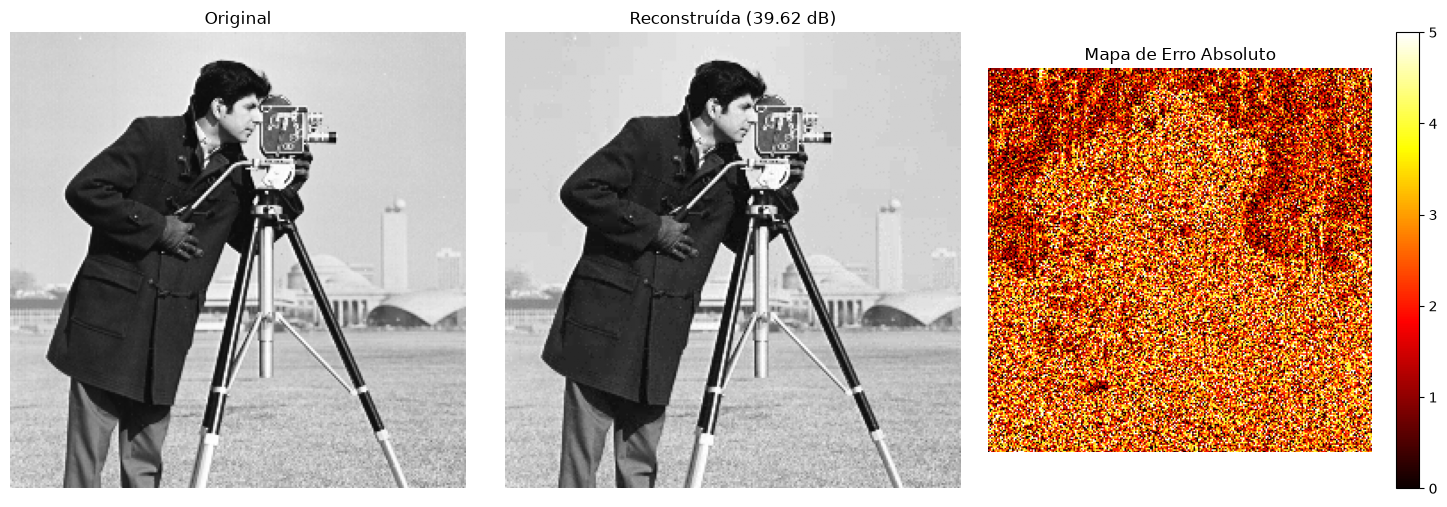

In [317]:
img = mpimg.imread(getImageName(0))  
run(img)

Tamanho Original: 240000 bytes (1920000 bits)
Tamanho Comprimido: 134870 bytes (1078966 bits)
Taxa de Compressão: 1.78x
Bitrate: 4.50 bpp
MSE: 8.46
PSNR: 38.86 dB


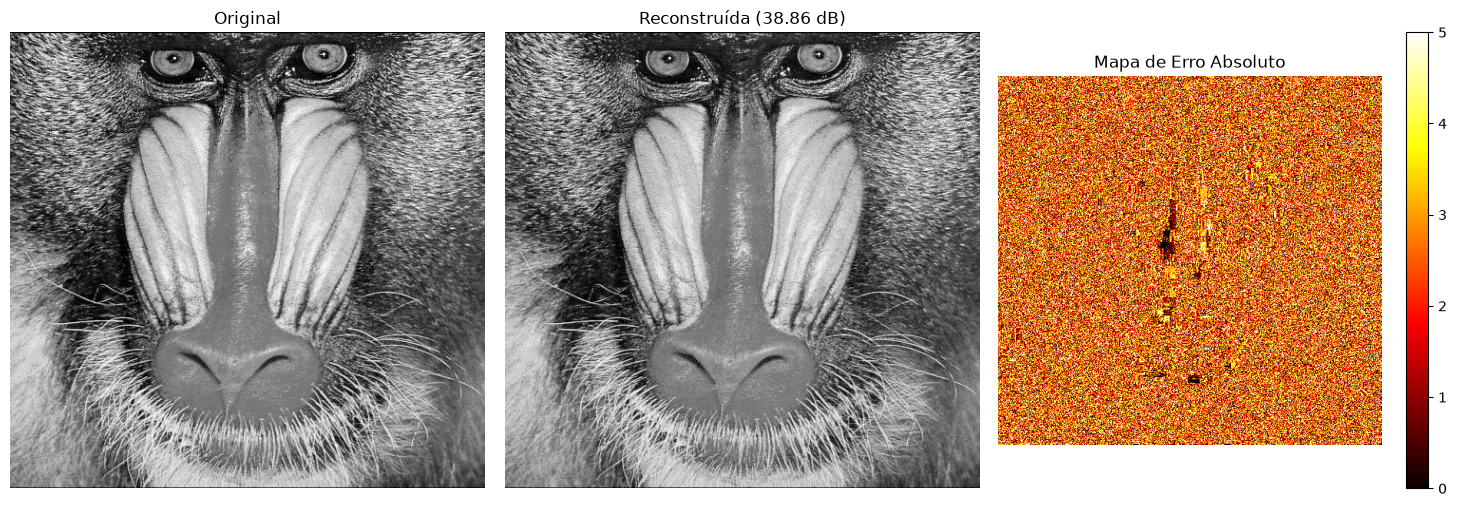

In [318]:
img = mpimg.imread(getImageName(1))  
run(img)

Tamanho Original: 262144 bytes (2097152 bits)
Tamanho Comprimido: 76366 bytes (610934 bits)
Taxa de Compressão: 3.43x
Bitrate: 2.33 bpp
MSE: 7.47
PSNR: 39.40 dB


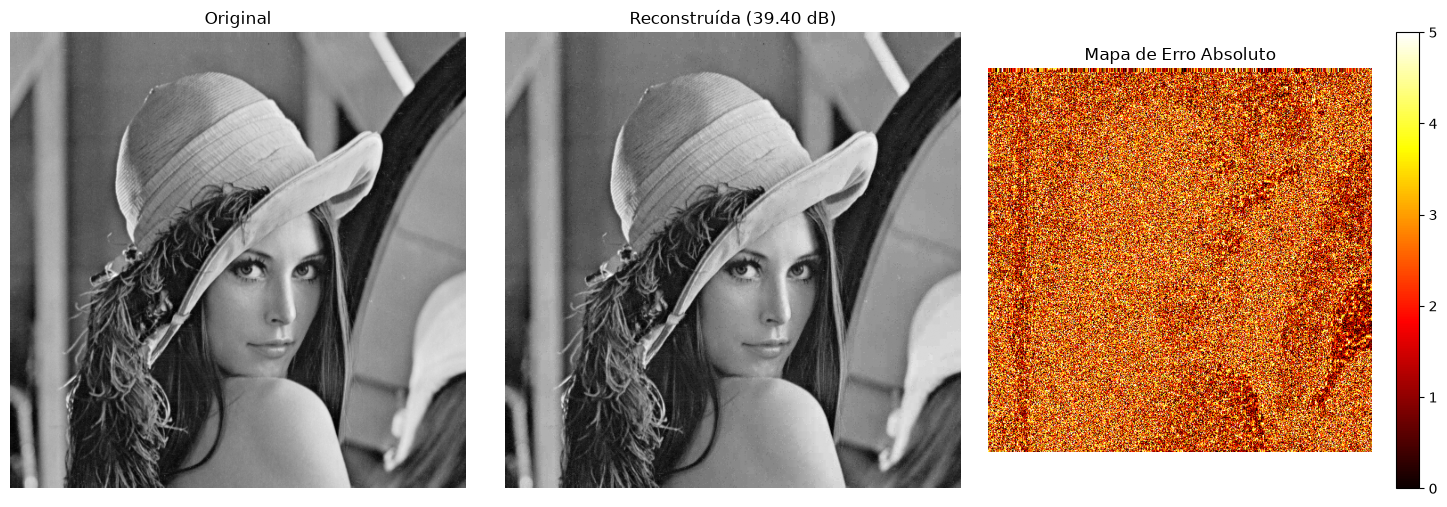

In [319]:
img = mpimg.imread(getImageName(2))  
run(img)

Tamanho Original: 160000 bytes (1280000 bits)
Tamanho Comprimido: 27963 bytes (223708 bits)
Taxa de Compressão: 5.72x
Bitrate: 1.40 bpp
MSE: 4.38
PSNR: 41.72 dB


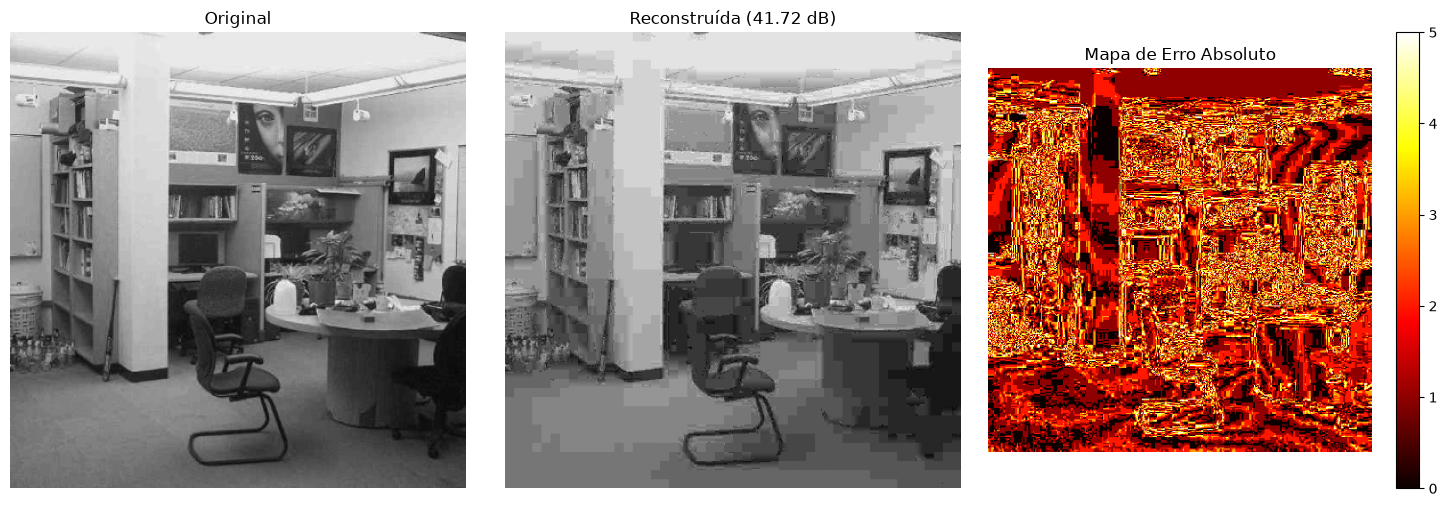

In [320]:
img = mpimg.imread(getImageName(3))  
run(img)

Tamanho Original: 290400 bytes (2323200 bits)
Tamanho Comprimido: 189805 bytes (1518446 bits)
Taxa de Compressão: 1.53x
Bitrate: 5.23 bpp
MSE: 7.69
PSNR: 39.27 dB


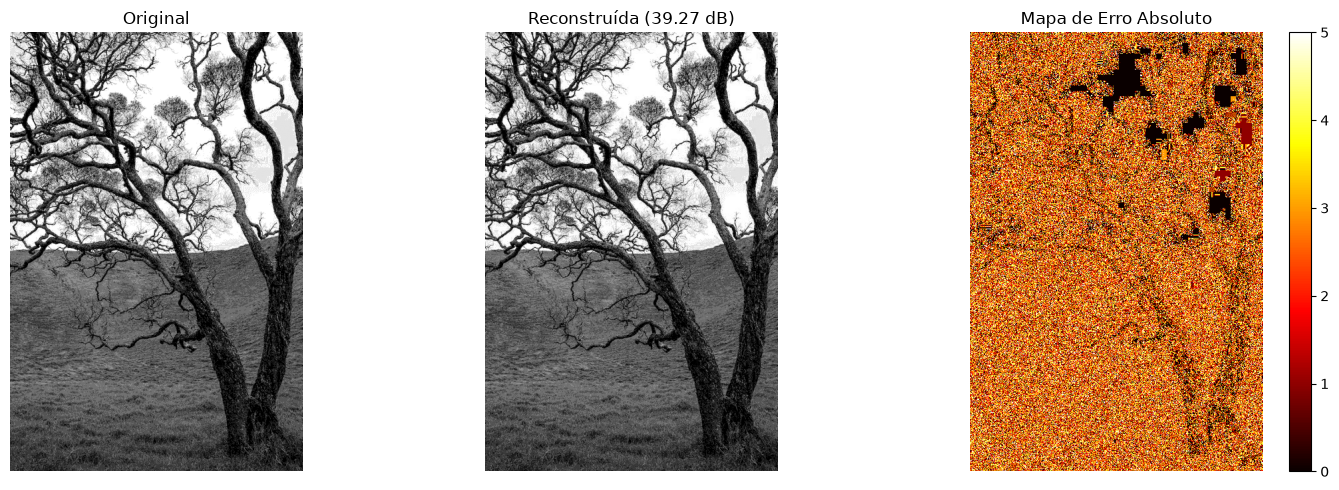

In [321]:
img = mpimg.imread(getImageName(4))  
run(img)

In [ ]:
img = mpimg.imread(getImageName(5))  
run(img)